In [33]:
from langchain_groq import ChatGroq
from langgraph.graph import StateGraph, START, END
from typing import TypedDict


In [34]:
class batsman_state(TypedDict):
    runs: int
    balls: int
    fours: int
    sixes: int

    sr : float
    bp : float
    bpb : float

In [41]:
graph = StateGraph(batsman_state)

In [ ]:
def strike_rate(state: batsman_state) -> batsman_state:
    if state["balls"] == 0:
        return {"sr": 0}

    return {
        "sr": (state["runs"] / state["balls"]) * 100
    }


def boundary_percentage(state: batsman_state) -> batsman_state:
    boundary_runs = state["fours"] * 4 + state["sixes"] * 6

    if state["runs"] == 0:
        return {"bp": 0}

    return {
        "bp": (boundary_runs / state["runs"]) * 100
    }


def balls_per_boundary(state: batsman_state) -> batsman_state:
    total_boundaries = state["fours"] + state["sixes"]

    if total_boundaries == 0:
        return {"bpb": 0}

    return {
        "bpb": state["balls"] / total_boundaries
    }


def summary(state: batsman_state) -> batsman_state:
    return {
        "summary": (
            f"Runs: {state['runs']}, "
            f"Balls: {state['balls']}, "
            f"Fours: {state['fours']}, "
            f"Sixes: {state['sixes']}, "
            f"Strike Rate: {state['sr']:.2f}, "
            f"Boundary Percentage: {state['bp']:.2f}%, "
            f"Balls per Boundary: {state['bpb']:.2f}"
        )
    }

In [43]:
graph.add_node("calculate_strike_rate", strike_rate)
graph.add_node("calculate_boundary_percentage", boundary_percentage)
graph.add_node("calculate_balls_per_boundary", balls_per_boundary)
graph.add_node("summary", summary)


graph.add_edge(START, "calculate_strike_rate")
graph.add_edge(START, "calculate_boundary_percentage")
graph.add_edge(START, "calculate_balls_per_boundary")


graph.add_edge(
    [
        "calculate_strike_rate",
        "calculate_boundary_percentage",
        "calculate_balls_per_boundary"
    ],
    "summary"
)

graph.add_edge("summary", END)


workflow = graph.compile()

In [44]:
initial_state = {"runs": 50, 
                 "balls": 100, 
                 "fours": 5, 
                 "sixes": 2}


final_state = workflow.invoke(initial_state)

In [45]:
final_state

{'runs': 50,
 'balls': 100,
 'fours': 5,
 'sixes': 2,
 'sr': 50.0,
 'bp': 64.0,
 'bpb': 14.285714285714286}

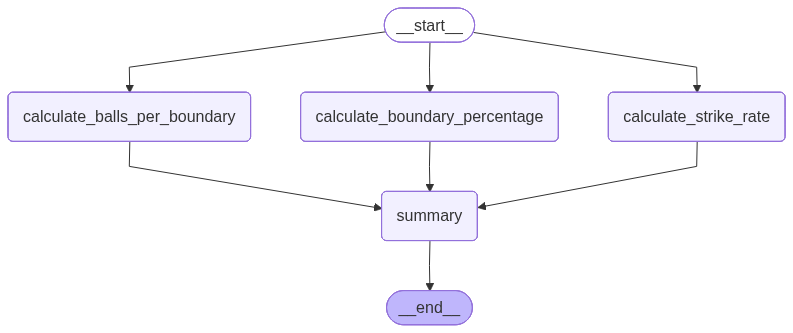

In [47]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())